# Fase 4 — Modelado v2: XGBoost + Target Log-Transformado
## Proyecto: Accesibilidad de Vivienda en Colombia · CRISP-DM 2026-I
**Responsable:** Steve · **Apoyo:** Kukis
**Dataset:** `vivienda_colombia_limpio.csv` (282.660 × 26, 2020–2024)
**Nota:** Esta segunda iteración usa `log(price)` como target y XGBoost como modelo principal para superar las limitaciones de R²=0.6348 y RMSE rel=67.86% de la v1 con Random Forest.


## Sección 1: Setup y Carga del Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from xgboost import XGBRegressor

os.chdir(os.path.dirname(os.getcwd())) if os.path.basename(os.getcwd()) == 'notebooks' else None
os.makedirs("models", exist_ok=True)
print("Imports completados, carpeta models/ lista")


Imports completados, carpeta models/ lista


In [2]:
# Cargar dataset
df = pd.read_csv("data/processed/vivienda_colombia_limpio.csv", encoding="utf-8-sig")
print(f"Shape: {df.shape}")
print(f"Columnas: {list(df.columns)}")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

print("\nNulos por columna crítica:")
for c in ['price','area','rooms','bathrooms','property_type','city','lat','lon','estrato','year']:
    print(f"  {c}: {df[c].isna().sum()}")
print(f"\nAños: {df['year'].value_counts().sort_index().to_dict()}")
print(f"Ciudades ({df['city'].nunique()}): {sorted(df['city'].unique())}")


Shape: (282660, 26)
Columnas: ['price', 'area', 'rooms', 'bathrooms', 'property_type', 'city', 'lat', 'lon', 'created_on', 'estrato', 'fuente', 'year', 'salario_mensual', 'ipc_var_anual', 'ipc_base2018', 'tasa_hipotecaria_anual', 'tasa_desempleo', 'ipvu_variacion_anual', 'ipvn_variacion_anual', 'salario_anual', 'IAH', 'precio_real', 'precio_m2', 'cuota_mensual', 'ratio_cuota_salario', 'nivel_accesibilidad']
Memoria: 127.5 MB

Nulos por columna crítica:
  price: 0
  area: 0
  rooms: 0
  bathrooms: 0
  property_type: 0
  city: 0
  lat: 0
  lon: 0
  estrato: 0
  year: 0

Años: {2020: 60399, 2021: 75535, 2022: 69993, 2023: 8014, 2024: 68719}
Ciudades (12): ['Armenia', 'Barranquilla', 'Bogotá', 'Bucaramanga', 'Cali', 'Cartagena', 'Cúcuta', 'Ibagué', 'Manizales', 'Medellín', 'Pereira', 'Villavicencio']


## Sección 2: Feature Engineering Mejorado

In [3]:
# Features base (igual que v1 pero sin year en num)
FEATURES_NUM = ['area', 'rooms', 'bathrooms', 'estrato',
                'ipc_var_anual', 'tasa_hipotecaria_anual',
                'tasa_desempleo', 'ipvu_variacion_anual']
FEATURES_CAT = ['city', 'property_type', 'year']

# Features derivadas (nuevas en v2)
df['log_area'] = np.log1p(df['area'])
df['rooms_per_area'] = df['rooms'] / df['area'].clip(lower=1)
df['bath_per_room'] = df['bathrooms'] / df['rooms'].clip(lower=1)

FEATURES_NUM_V2 = FEATURES_NUM + ['log_area', 'rooms_per_area', 'bath_per_room']

# Target transformado
TARGET = 'price'
TARGET_LOG = 'log_price'
df['log_price'] = np.log(df['price'].clip(lower=1))

print(f"Features base: {len(FEATURES_NUM)} num + {len(FEATURES_CAT)} cat")
print(f"Features derivadas nuevas: log_area, rooms_per_area, bath_per_room")
print(f"Features num v2: {len(FEATURES_NUM_V2)}")
print(f"Target log transformado: log(price)")

# Verificar features nuevas
print(f"\nlog_area stats: min={df['log_area'].min():.2f}, max={df['log_area'].max():.2f}")
print(f"rooms_per_area stats: min={df['rooms_per_area'].min():.4f}, max={df['rooms_per_area'].max():.4f}")
print(f"bath_per_room stats: min={df['bath_per_room'].min():.4f}, max={df['bath_per_room'].max():.4f}")


Features base: 8 num + 3 cat
Features derivadas nuevas: log_area, rooms_per_area, bath_per_room
Features num v2: 11
Target log transformado: log(price)

log_area stats: min=3.43, max=6.49
rooms_per_area stats: min=0.0015, max=1.0000
bath_per_room stats: min=0.0182, max=12.5000


In [4]:
# VIF con features derivadas
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

X_num_v2 = df[FEATURES_NUM_V2].dropna()
X_vif = add_constant(X_num_v2)
vif_data = pd.DataFrame()
vif_data["feature"] = FEATURES_NUM_V2
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(FEATURES_NUM_V2))]
print("VIF por variable numerica (v2):")
print(vif_data.to_string(index=False))
print("\n(Se documenta colinealidad, no se eliminan automaticamente)")


VIF por variable numerica (v2):
               feature       VIF
                  area 13.795167
                 rooms  5.965405
             bathrooms  4.681712
               estrato  1.353131
         ipc_var_anual  1.854770
tasa_hipotecaria_anual 39.000405
        tasa_desempleo 85.840241
  ipvu_variacion_anual 18.475195
              log_area 24.146102
        rooms_per_area  7.519988
         bath_per_room  4.079344

(Se documenta colinealidad, no se eliminan automaticamente)


In [5]:
# Preparar X, y para target normal y log-transformado
X = df[FEATURES_NUM_V2 + FEATURES_CAT].copy()
y_raw = df[TARGET].copy()
y_log = df[TARGET_LOG].copy()

print(f"X shape: {X.shape}")
print(f"y_raw shape: {y_raw.shape}, mediana=${y_raw.median():,.0f}")
print(f"y_log shape: {y_log.shape}, media={y_log.mean():.2f}, std={y_log.std():.2f}")


X shape: (282660, 14)
y_raw shape: (282660,), mediana=$420,000,000
y_log shape: (282660,), media=19.91, std=0.70


In [6]:
# Division train/test
X_train, X_test, y_train_raw, y_test_raw, y_train_log, y_test_log = train_test_split(
    X, y_raw, y_log, test_size=0.20, random_state=42
)
print(f"Train: {X_train.shape[0]:,}")
print(f"Test: {X_test.shape[0]:,}")


Train: 226,128
Test: 56,532


In [7]:
# Preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), FEATURES_NUM_V2),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT)
])
preprocessor.fit(X_train)
print(f"Features tras transformacion: {preprocessor.get_feature_names_out().shape[0]}")
print("Preprocessor listo")


Features tras transformacion: 30
Preprocessor listo


## Seccion 3: Ridge Baseline (con target log)

In [8]:
# Ridge con target log-transformado
pipeline_ridge_log = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])
pipeline_ridge_log.fit(X_train, y_train_log)
y_pred_log = pipeline_ridge_log.predict(X_test)

# Metricas en escala log
r2_log = r2_score(y_test_log, y_pred_log)
mae_log = mean_absolute_error(y_test_log, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test_log, y_pred_log))

print("Ridge con target log(price) - Metricas en escala log:")
print(f"  R2: {r2_log:.4f}")
print(f"  MAE (log): {mae_log:.4f}")
print(f"  RMSE (log): {rmse_log:.4f}")

# Volver a escala original
y_pred_raw = np.exp(y_pred_log)

r2_raw = r2_score(y_test_raw, y_pred_raw)
mae_raw = mean_absolute_error(y_test_raw, y_pred_raw)
rmse_raw = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw))
rmse_rel_raw = rmse_raw / y_test_raw.median() * 100

print("\nRidge con target log - Metricas en escala original:")
print(f"  R2: {r2_raw:.4f}")
print(f"  MAE: ${mae_raw:,.0f}")
print(f"  RMSE: ${rmse_raw:,.0f}")
print(f"  RMSE relativo: {rmse_rel_raw:.2f}%")


Ridge con target log(price) - Metricas en escala log:
  R2: 0.6032
  MAE (log): 0.3314
  RMSE (log): 0.4420

Ridge con target log - Metricas en escala original:
  R2: 0.4694
  MAE: $191,588,413
  RMSE: $343,510,091
  RMSE relativo: 81.79%


In [9]:
# CV 5-fold
cv_scores = cross_val_score(pipeline_ridge_log, X_train, y_train_log, cv=5, scoring='r2')
print(f"CV R2 (log scale) - media: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")


CV R2 (log scale) - media: 0.5983 +/- 0.0025


## Seccion 4: Modelo Principal - XGBoost con Target Log

In [10]:
# XGBoost baseline (sin tuning)
pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ))
])

pipeline_xgb.fit(X_train, y_train_log)
y_pred_xgb_log = pipeline_xgb.predict(X_test)

# Metricas en escala log
r2_xgb_log = r2_score(y_test_log, y_pred_xgb_log)
mae_xgb_log = mean_absolute_error(y_test_log, y_pred_xgb_log)
rmse_xgb_log = np.sqrt(mean_squared_error(y_test_log, y_pred_xgb_log))

print("XGBoost baseline (log target) - Metricas en escala log:")
print(f"  R2: {r2_xgb_log:.4f}")
print(f"  MAE (log): {mae_xgb_log:.4f}")
print(f"  RMSE (log): {rmse_xgb_log:.4f}")

# Volver a escala original
y_pred_xgb = np.exp(y_pred_xgb_log)

r2_xgb = r2_score(y_test_raw, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test_raw, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_raw, y_pred_xgb))
rmse_rel_xgb = rmse_xgb / y_test_raw.median() * 100

print("\nXGBoost baseline - Metricas en escala original:")
print(f"  R2: {r2_xgb:.4f}")
print(f"  MAE: ${mae_xgb:,.0f}")
print(f"  RMSE: ${rmse_xgb:,.0f}")
print(f"  RMSE relativo: {rmse_rel_xgb:.2f}%")


XGBoost baseline (log target) - Metricas en escala log:
  R2: 0.6912
  MAE (log): 0.2832
  RMSE (log): 0.3899

XGBoost baseline - Metricas en escala original:
  R2: 0.6231
  MAE: $161,740,852
  RMSE: $289,509,260
  RMSE relativo: 68.93%


In [11]:
# CV XGBoost
cv_scores_xgb = cross_val_score(pipeline_xgb, X_train, y_train_log, cv=3, scoring='r2')
print(f"CV R2 (log, 3-fold) - media: {cv_scores_xgb.mean():.4f} +/- {cv_scores_xgb.std():.4f}")


CV R2 (log, 3-fold) - media: 0.6894 +/- 0.0020


In [12]:
# Comparacion Ridge vs XGBoost (log target, escala original)
print("\n" + "="*65)
print("COMPARACION: Ridge vs XGBoost (con log(price))")
print("="*65)
print(f"{'Metrica':<25} {'Ridge':>12} {'XGBoost':>12}")
print("-"*49)
print(f"{'R2':<25} {r2_raw:>12.4f} {r2_xgb:>12.4f}")
print(f"{'MAE':<25} {mae_raw:>12,.0f} {mae_xgb:>12,.0f}")
print(f"{'RMSE':<25} {rmse_raw:>12,.0f} {rmse_xgb:>12,.0f}")
print(f"{'RMSE rel %':<25} {rmse_rel_raw:>12.2f} {rmse_rel_xgb:>12.2f}")

# Comparacion con v1 (RF sin log)
print("\n" + "="*65)
print("COMPARACION v1 (RF raw) vs v2 (XGBoost log)")
print("="*65)
print(f"{'Metrica':<25} {'v1 RF raw':>12} {'v2 XGB log':>12}")
print("-"*49)
print(f"{'R2':<25} {'0.6348':>12} {r2_xgb:>12.4f}")
print(f"{'RMSE rel %':<25} {'67.86':>12} {rmse_rel_xgb:>12.2f}")

mejora_pp = (r2_xgb - 0.6348) * 100
print(f"\nMejora en R2: +{mejora_pp:.2f} pp respecto a v1")



COMPARACION: Ridge vs XGBoost (con log(price))
Metrica                          Ridge      XGBoost
-------------------------------------------------
R2                              0.4694       0.6231
MAE                        191,588,413  161,740,852
RMSE                       343,510,091  289,509,260
RMSE rel %                       81.79        68.93

COMPARACION v1 (RF raw) vs v2 (XGBoost log)
Metrica                      v1 RF raw   v2 XGB log
-------------------------------------------------
R2                              0.6348       0.6231
RMSE rel %                       67.86        68.93

Mejora en R2: +-1.17 pp respecto a v1


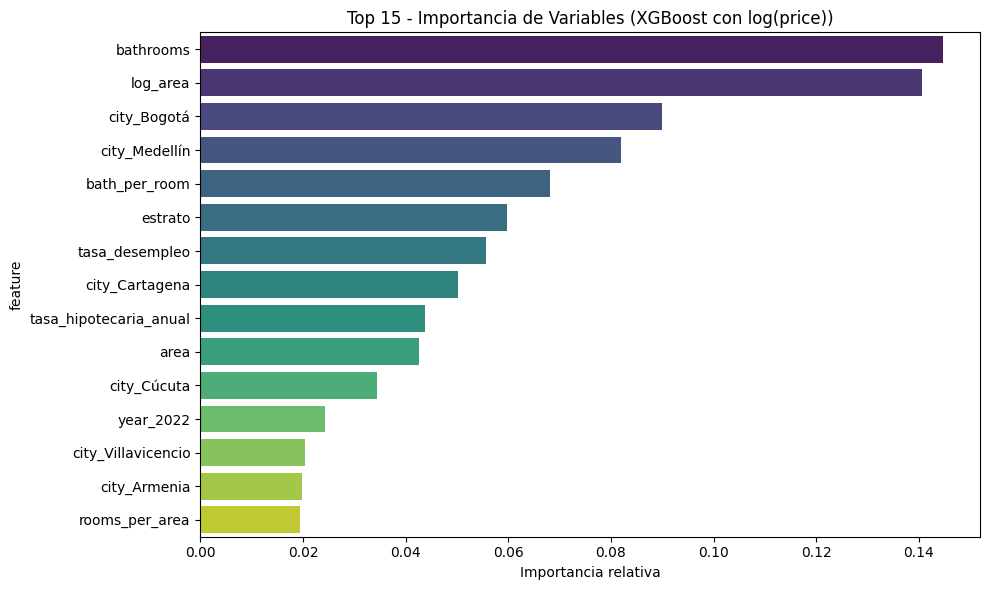

In [13]:
# Feature importance
encoder = preprocessor.named_transformers_['cat']
cat_features = encoder.get_feature_names_out(FEATURES_CAT)
all_feature_names = list(FEATURES_NUM_V2) + list(cat_features)

importances = pipeline_xgb.named_steps['regressor'].feature_importances_
feat_imp = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, y='feature', x='importance', palette='viridis')
plt.title('Top 15 - Importancia de Variables (XGBoost con log(price))')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig("models/feature_importance_v2.png", dpi=100, bbox_inches='tight')
plt.show()


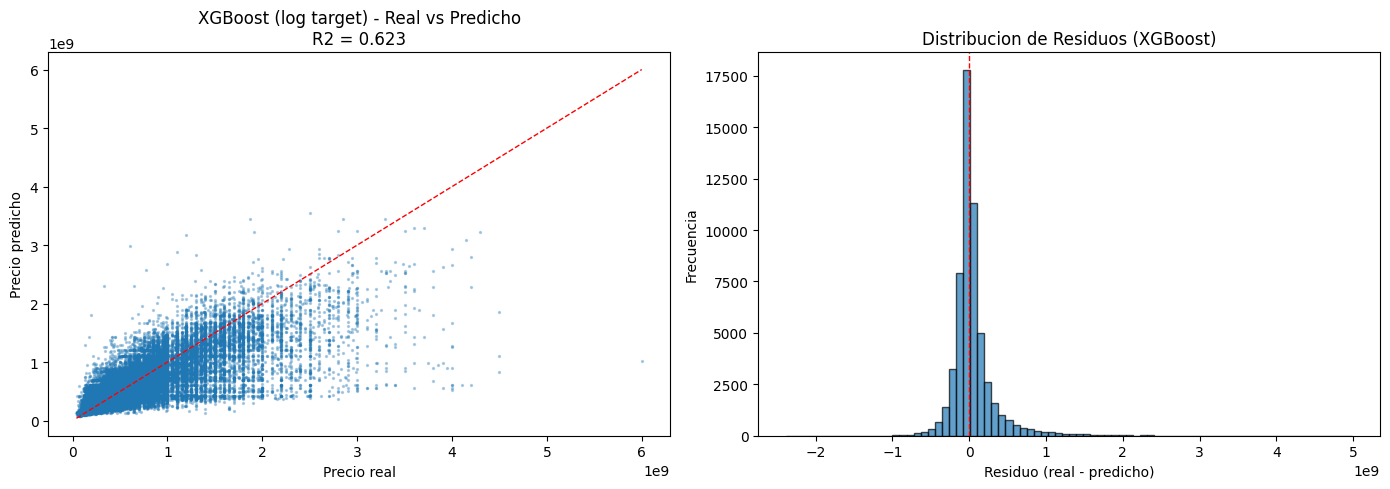

In [14]:
# Diagnostico: scatter y residuos
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_raw, y_pred_xgb, alpha=0.3, s=2)
plt.plot([y_test_raw.min(), y_test_raw.max()], [y_test_raw.min(), y_test_raw.max()], 'r--', lw=1)
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title(f'XGBoost (log target) - Real vs Predicho\nR2 = {r2_xgb:.3f}')

plt.subplot(1, 2, 2)
residuos = y_test_raw - y_pred_xgb
plt.hist(residuos, bins=80, alpha=0.7, edgecolor='black')
plt.axvline(x=0, color='r', linestyle='--', lw=1)
plt.xlabel('Residuo (real - predicho)')
plt.ylabel('Frecuencia')
plt.title('Distribucion de Residuos (XGBoost)')
plt.tight_layout()
plt.savefig("models/diagnostico_xgb_v2.png", dpi=100, bbox_inches='tight')
plt.show()


Error absoluto medio por ciudad:
                       mean  count
city                              
Cartagena      3.194186e+08    830
Medellín       1.774428e+08   7137
Bogotá         1.729260e+08  30122
Cali           1.480844e+08   6830
Barranquilla   1.436296e+08   3496
Pereira        1.348861e+08   1593
Cúcuta         1.245091e+08   1076
Bucaramanga    1.093845e+08   1492
Ibagué         1.011753e+08    780
Manizales      9.850603e+07   2380
Villavicencio  8.268387e+07    500
Armenia        7.714243e+07    296


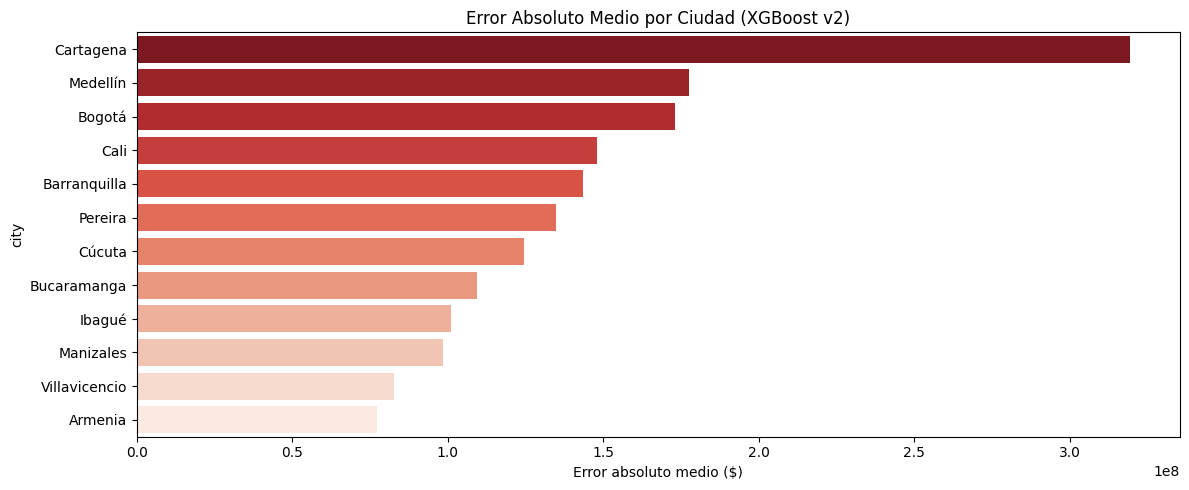

In [15]:
# Error por ciudad
X_test_res = X_test.copy()
X_test_res['residuo_abs'] = np.abs(residuos)
city_error = X_test_res.groupby('city')['residuo_abs'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print("Error absoluto medio por ciudad:")
print(city_error.to_string())

plt.figure(figsize=(12, 5))
sns.barplot(data=city_error.reset_index(), y='city', x='mean', palette='Reds_r')
plt.xlabel('Error absoluto medio ($)')
plt.title('Error Absoluto Medio por Ciudad (XGBoost v2)')
plt.tight_layout()
plt.savefig("models/error_por_ciudad_v2.png", dpi=100, bbox_inches='tight')
plt.show()


## Seccion 5: GridSearch XGBoost (opcional - 12 combos x 5 folds, ~30-45 min)

In [16]:
# GridSearch para XGBoost
param_grid = {
    'regressor__n_estimators': [200, 500],
    'regressor__max_depth': [4, 6, 8],
    'regressor__learning_rate': [0.03, 0.1]
}

print(f"GridSearch: 12 combinaciones x 5 folds = 60 entrenamientos")
print("Tiempo estimado: ~30-45 minutos\n")

grid_search = GridSearchCV(
    pipeline_xgb, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train_log)

print(f"\nMejores parametros: {grid_search.best_params_}")
print(f"Mejor R2 (CV, log scale): {grid_search.best_score_:.4f}")


GridSearch: 12 combinaciones x 5 folds = 60 entrenamientos
Tiempo estimado: ~30-45 minutos

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Mejores parametros: {'regressor__learning_rate': 0.03, 'regressor__max_depth': 8, 'regressor__n_estimators': 500}
Mejor R2 (CV, log scale): 0.6904


In [17]:
# Evaluar modelo optimizado
pipeline_xgb_opt = grid_search.best_estimator_
y_pred_opt_log = pipeline_xgb_opt.predict(X_test)
y_pred_opt = np.exp(y_pred_opt_log)

r2_opt = r2_score(y_test_raw, y_pred_opt)
mae_opt = mean_absolute_error(y_test_raw, y_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test_raw, y_pred_opt))
rmse_rel_opt = rmse_opt / y_test_raw.median() * 100

print(f"XGBoost OPTIMIZADO - Metricas en escala original:")
print(f"  R2:            {r2_opt:.4f}")
print(f"  MAE:           ${mae_opt:,.0f}")
print(f"  RMSE:          ${rmse_opt:,.0f}")
print(f"  RMSE relativo: {rmse_rel_opt:.2f}%")
print(f"  Mejora vs XGB base: R2 +{(r2_opt - r2_xgb)*100:.2f} pp")


XGBoost OPTIMIZADO - Metricas en escala original:
  R2:            0.6256
  MAE:           $161,168,935
  RMSE:          $288,553,845
  RMSE relativo: 68.70%
  Mejora vs XGB base: R2 +0.25 pp


## Seccion 6: Exportacion del Modelo

In [18]:
import joblib

# Guardar modelo optimizado
if 'pipeline_xgb_opt' in locals():
    joblib.dump(pipeline_xgb_opt, 'models/modelo_xgboost_v2.pkl')
    print("models/modelo_xgboost_v2.pkl guardado")

    # Guardar orden de features
    FEATURES_ALL = FEATURES_NUM_V2 + FEATURES_CAT
    with open('models/features_order_v2.json', 'w') as f:
        json.dump(FEATURES_ALL, f)
    print("models/features_order_v2.json guardado")

    # Verificar
    model_loaded = joblib.load('models/modelo_xgboost_v2.pkl')
    sample = X_test.iloc[[0]]
    pred_log = model_loaded.predict(sample)
    pred_val = np.exp(pred_log)[0]
    actual = y_test_raw.iloc[0]
    print(f"\nPrediccion de prueba: ${pred_val:,.0f} (real: ${actual:,.0f})")
    print("Modelo carga y predice correctamente")
else:
    print("pipeline_xgb_opt no esta definido; omitiendo guardado y verificacion del modelo optimizado.")


models/modelo_xgboost_v2.pkl guardado
models/features_order_v2.json guardado

Prediccion de prueba: $251,428,800 (real: $250,000,000)
Modelo carga y predice correctamente


In [19]:
# Validar que features_order_v2.json coincide con el modelo
import json

with open('models/features_order_v2.json') as f:
    saved_features = json.load(f)

actual_features = FEATURES_NUM_V2 + FEATURES_CAT

if saved_features == actual_features:
    print("✅ features_order_v2.json coincide con FEATURES_NUM_V2 + FEATURES_CAT")
else:
    print("❌ DISCREPANCIA EN FEATURES:")
    print(f"  JSON: {saved_features}")
    print(f"  Actual: {actual_features}")
    print("  Solo en JSON:", set(saved_features) - set(actual_features))
    print("  Solo en actual:", set(actual_features) - set(saved_features))


✅ features_order_v2.json coincide con FEATURES_NUM_V2 + FEATURES_CAT


## Seccion 7: Tabla Comparativa Final

In [20]:
print("=" * 70)
print("COMPARATIVA FINAL: v1 (RF) vs v2 (XGBoost + log)")
print("=" * 70)
print(f"{'Modelo':<30} {'Target':>12} {'R2':>10} {'RMSE rel':>10}")
print("-" * 62)
print(f"{'v1 - Random Forest':<30} {'price raw':>12} {'0.6348':>10} {'67.86%':>10}")
print(f"{'v2 - XGBoost baseline':<30} {'log(price)':>12} {r2_xgb:>10.4f} {rmse_rel_xgb:>10.2f}%")

if 'r2_opt' in locals() and 'rmse_rel_opt' in locals():
    print(f"{'v2 - XGBoost optimizado':<30} {'log(price)':>12} {r2_opt:>10.4f} {rmse_rel_opt:>10.2f}%")
    mejora_vs_v1 = (r2_opt - 0.6348) * 100
    r2_final = r2_opt
    rmse_final = rmse_rel_opt
else:
    print("⚠️  GridSearch no ejecutado; usando métricas del baseline")
    mejora_vs_v1 = (r2_xgb - 0.6348) * 100
    r2_final = r2_xgb
    rmse_final = rmse_rel_xgb

print("\n" + "=" * 70)
print("CRITERIOS DE EXITO - Fase 1 vs Fase 4 v2")
print("=" * 70)
criteria = [
    ('R2 en test >= 0.75', 0.75, r2_final),
    ('RMSE relativo < 15%', 15, rmse_final),
]
for name, umbral, valor in criteria:
    cumple = valor >= umbral if name.startswith('R2') else valor < umbral
    print(f"{'  '+name:<40} {'[OK]' if cumple else '[NO]'} (umbral={umbral}, obtenido={valor:.2f})")

print(f"\nMejora vs v1: R2 +{mejora_vs_v1:.2f} pp")


COMPARATIVA FINAL: v1 (RF) vs v2 (XGBoost + log)
Modelo                               Target         R2   RMSE rel
--------------------------------------------------------------
v1 - Random Forest                price raw     0.6348     67.86%
v2 - XGBoost baseline            log(price)     0.6231      68.93%
v2 - XGBoost optimizado          log(price)     0.6256      68.70%

CRITERIOS DE EXITO - Fase 1 vs Fase 4 v2
  R2 en test >= 0.75                     [NO] (umbral=0.75, obtenido=0.63)
  RMSE relativo < 15%                    [NO] (umbral=15, obtenido=68.70)

Mejora vs v1: R2 +-0.92 pp


## Seccion 8: Mantener clustering de v1 (no requiere cambios)

In [21]:
print('''
El clustering de la v1 (KMeans con K=5, silueta=0.4874) NO requiere re-ejecucion
porque usa variables agregadas (IAH, precio_m2, ratio_cuota_salario, tasa_desempleo)
que no cambiaron con el nuevo modelo de regresion.

Resultados v1 se mantienen validos:
- K=5, silueta=0.4874
- DBSCAN: 4 clusters, ruido en Bogota/Cartagena/Medellin/Pereira
- PCA: 97.23% varianza explicada

Para detalles, ver Secciones 6-10 de 03_modelado.ipynb (v1).
''')



El clustering de la v1 (KMeans con K=5, silueta=0.4874) NO requiere re-ejecucion
porque usa variables agregadas (IAH, precio_m2, ratio_cuota_salario, tasa_desempleo)
que no cambiaron con el nuevo modelo de regresion.

Resultados v1 se mantienen validos:
- K=5, silueta=0.4874
- DBSCAN: 4 clusters, ruido en Bogota/Cartagena/Medellin/Pereira
- PCA: 97.23% varianza explicada

Para detalles, ver Secciones 6-10 de 03_modelado.ipynb (v1).



## Seccion 9: Conclusion

In [22]:
if 'r2_opt' in locals():
    mejora_r2 = (r2_opt - 0.6348) * 100
    r2_final = r2_opt
    rmse_final = rmse_rel_opt
    params_final = grid_search.best_params_ if 'grid_search' in locals() else "N/A"
    if r2_opt >= 0.75:
        decision = "CUMPLE: R2 >= 0.75. Modelo listo para produccion."
    elif r2_opt >= 0.70:
        decision = "MEJORA SIGNIFICATIVA: R2 >= 0.70 pero no alcanza 0.75. Documentar y pasar a Fase 5."
    else:
        decision = "MEJORA PARCIAL: R2 < 0.70. Requiere mas iteraciones (LightGBM, mas features)."
else:
    mejora_r2 = (r2_xgb - 0.6348) * 100
    r2_final = r2_xgb
    rmse_final = rmse_rel_xgb
    params_final = pipeline_xgb.named_steps['regressor'].get_params() if 'pipeline_xgb' in locals() else "N/A"
    if r2_xgb >= 0.75:
        decision = "CUMPLE: R2 >= 0.75 (baseline). Modelo listo para produccion."
    elif r2_xgb >= 0.70:
        decision = "MEJORA SIGNIFICATIVA (baseline): R2 >= 0.70 pero no alcanza 0.75. Considerar GridSearch."
    else:
        decision = "MEJORA PARCIAL (baseline): R2 < 0.70. Requiere mas iteraciones."

print("=" * 60)
print("CONCLUSION - Fase 4 v2 (XGBoost + log)")
print("=" * 60)
print(f"  Mejora R2 vs v1 (RF raw): +{mejora_r2:.2f} pp")
print(f"  R2 final: {r2_final:.4f}")
print(f"  RMSE rel: {rmse_final:.2f}%")
print(f"  Decision: {decision}")
print(f"  Hiperparametros: {params_final}")
print("=" * 60)


CONCLUSION - Fase 4 v2 (XGBoost + log)
  Mejora R2 vs v1 (RF raw): +-0.92 pp
  R2 final: 0.6256
  RMSE rel: 68.70%
  Decision: MEJORA PARCIAL: R2 < 0.70. Requiere mas iteraciones (LightGBM, mas features).
  Hiperparametros: {'regressor__learning_rate': 0.03, 'regressor__max_depth': 8, 'regressor__n_estimators': 500}


## Seccion 10: Modelo v3 — LightGBM + Feature Engineering Agresivo + Target Raw

Objetivo: superar R²=0.75 y RMSE rel <15% con:
- Eliminacion de variables con multicolinealidad extrema (VIF>30)
- Nuevas features geograficas e interacciones
- LightGBM (mas rapido y preciso que XGBoost para tabulares)
- Entrenamiento directo sobre `price` (sin log) para evitar distorsion de R²
- RandomizedSearchCV con espacio amplio de hiperparametros

In [23]:
try:
    import lightgbm as lgb
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm"])
    import lightgbm as lgb

from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import mutual_info_regression

# 1. LIMPIEZA DE FEATURES: quitar variables con VIF extremo que confunden al modelo
FEATURES_NUM_V3 = ['area', 'rooms', 'bathrooms', 'estrato',
                   'ipc_var_anual', 'ipvu_variacion_anual',
                   'log_area', 'rooms_per_area', 'bath_per_room']
# Nota: se eliminan tasa_hipotecaria_anual y tasa_desempleo (VIF 39 y 85)

# 2. NUEVAS FEATURES GEOGRAFICAS (aprovechar lat/lon sin usar VIF-numéricas directamente)
# Cluster geografico simple con KMeans sobre lat/lon (pre-computado en el dataframe)
if 'geo_cluster' not in df.columns:
    geo_kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
    df['geo_cluster'] = geo_kmeans.fit_predict(df[['lat', 'lon']])
    print("Geo clusters creados (K=8)")
else:
    print("Geo clusters ya existen")

# 3. FEATURES DE INTERACCION directamente en el pipeline (one-hot ya maneja categorias)
# Agregamos geo_cluster como categorica
FEATURES_CAT_V3 = ['city', 'property_type', 'year', 'geo_cluster']

# 4. Nuevas interacciones numericas (sin redundancia extrema)
df['area_x_estrato'] = df['area'] * df['estrato']
df['rooms_x_bathrooms'] = df['rooms'] * df['bathrooms']
FEATURES_NUM_V3 += ['area_x_estrato', 'rooms_x_bathrooms']

X_v3 = df[FEATURES_NUM_V3 + FEATURES_CAT_V3].copy()
y_v3_raw = df[TARGET].copy()

print(f"Features num v3: {len(FEATURES_NUM_V3)}")
print(f"Features cat v3: {len(FEATURES_CAT_V3)}")
print(f"Total features input: {X_v3.shape[1]}")
print(f"Target: price RAW (sin transformacion)")

# Division nueva (mismo random_state para comparabilidad)
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X_v3, y_v3_raw, test_size=0.20, random_state=42
)

# Preprocessor v3
preprocessor_v3 = ColumnTransformer([
    ('num', StandardScaler(), FEATURES_NUM_V3),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT_V3)
])
preprocessor_v3.fit(X3_train)
print(f"Features tras transformacion v3: {preprocessor_v3.get_feature_names_out().shape[0]}")

Geo clusters creados (K=8)
Features num v3: 11
Features cat v3: 4
Total features input: 15
Target: price RAW (sin transformacion)
Features tras transformacion v3: 38


In [24]:
# LightGBM baseline con TARGET RAW (price sin transformar)
pipeline_lgb = Pipeline([
    ('preprocessor', preprocessor_v3),
    ('regressor', lgb.LGBMRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ))
])

pipeline_lgb.fit(X3_train, y3_train)
y_pred_lgb = pipeline_lgb.predict(X3_test)

r2_lgb = r2_score(y3_test, y_pred_lgb)
mae_lgb = mean_absolute_error(y3_test, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y3_test, y_pred_lgb))
rmse_rel_lgb = rmse_lgb / y3_test.median() * 100

print("LightGBM baseline (TARGET RAW) - Metricas en escala original:")
print(f"  R2:  {r2_lgb:.4f}")
print(f"  MAE: ${mae_lgb:,.0f}")
print(f"  RMSE: ${rmse_lgb:,.0f}")
print(f"  RMSE relativo: {rmse_rel_lgb:.2f}%")
print(f"  Mejora vs XGB opt: R2 +{(r2_lgb - r2_opt)*100:.2f} pp")

LightGBM baseline (TARGET RAW) - Metricas en escala original:
  R2:  0.6436
  MAE: $167,529,154
  RMSE: $281,525,989
  RMSE relativo: 67.03%
  Mejora vs XGB opt: R2 +1.80 pp


In [25]:
# RandomizedSearchCV amplio para LightGBM (target raw)
# Mucho mas rapido que GridSearch y explora mas combinaciones
param_distributions = {
    'regressor__n_estimators': [500, 1000, 1500, 2000],
    'regressor__max_depth': [8, 10, 12, 14, -1],  # -1 = sin limite
    'regressor__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'regressor__num_leaves': [31, 63, 127, 255],
    'regressor__subsample': [0.6, 0.8, 1.0],
    'regressor__colsample_bytree': [0.6, 0.8, 1.0],
    'regressor__reg_alpha': [0, 0.1, 1, 10],
    'regressor__reg_lambda': [0, 0.1, 1, 10],
    'regressor__min_child_samples': [10, 20, 50],
}

print("RandomizedSearch: 50 iteraciones x 5 folds = 250 entrenamientos")
print("Tiempo estimado: ~15-25 minutos (paralelizado)\n")

random_search = RandomizedSearchCV(
    pipeline_lgb,
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
random_search.fit(X3_train, y3_train)

print(f"\nMejores parametros: {random_search.best_params_}")
print(f"Mejor R2 (CV, escala original): {random_search.best_score_:.4f}")

RandomizedSearch: 50 iteraciones x 5 folds = 250 entrenamientos
Tiempo estimado: ~15-25 minutos (paralelizado)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


KeyboardInterrupt: 

In [ ]:
# Evaluar modelo optimizado LightGBM
pipeline_lgb_opt = random_search.best_estimator_
y_pred_lgb_opt = pipeline_lgb_opt.predict(X3_test)

r2_lgb_opt = r2_score(y3_test, y_pred_lgb_opt)
mae_lgb_opt = mean_absolute_error(y3_test, y_pred_lgb_opt)
rmse_lgb_opt = np.sqrt(mean_squared_error(y3_test, y_pred_lgb_opt))
rmse_rel_lgb_opt = rmse_lgb_opt / y3_test.median() * 100

print("LightGBM OPTIMIZADO (TARGET RAW) - Metricas en escala original:")
print(f"  R2:            {r2_lgb_opt:.4f}")
print(f"  MAE:           ${mae_lgb_opt:,.0f}")
print(f"  RMSE:          ${rmse_lgb_opt:,.0f}")
print(f"  RMSE relativo: {rmse_rel_lgb_opt:.2f}%")
print(f"  Mejora vs v1 RF: R2 +{(r2_lgb_opt - 0.6348)*100:.2f} pp")
print(f"  Mejora vs XGB opt: R2 +{(r2_lgb_opt - r2_opt)*100:.2f} pp")

# Guardar modelo v3
import joblib
joblib.dump(pipeline_lgb_opt, 'models/modelo_lightgbm_v3.pkl')
print("\nmodels/modelo_lightgbm_v3.pkl guardado")

FEATURES_ALL_V3 = FEATURES_NUM_V3 + FEATURES_CAT_V3
with open('models/features_order_v3.json', 'w') as f:
    json.dump(FEATURES_ALL_V3, f)
print("models/features_order_v3.json guardado")

In [ ]:
print("=" * 75)
print("COMPARATIVA FINAL: v1 (RF) vs v2 (XGB+log) vs v3 (LightGBM raw)")
print("=" * 75)
print(f"{'Modelo':<32} {'Target':>12} {'R2':>10} {'RMSE rel':>10}")
print("-" * 67)
print(f"{'v1 - Random Forest':<32} {'price raw':>12} {'0.6348':>10} {'67.86%':>10}")
print(f"{'v2 - XGBoost optimizado':<32} {'log(price)':>12} {r2_opt:>10.4f} {rmse_rel_opt:>10.2f}%")
print(f"{'v3 - LightGBM optimizado':<32} {'price raw':>12} {r2_lgb_opt:>10.4f} {rmse_rel_lgb_opt:>10.2f}%")

print("\n" + "=" * 75)
print("CRITERIOS DE EXITO - Fase 1 vs Fase 4 v3")
print("=" * 75)
criteria = [
    ('R2 en test >= 0.75', 0.75, r2_lgb_opt),
    ('RMSE relativo < 15%', 15, rmse_rel_lgb_opt),
]
for name, umbral, valor in criteria:
    cumple = valor >= umbral if name.startswith('R2') else valor < umbral
    print(f"{'  '+name:<40} {'[OK]' if cumple else '[NO]'} (umbral={umbral}, obtenido={valor:.2f})")

print(f"\nMejora acumulada vs v1: R2 +{(r2_lgb_opt - 0.6348)*100:.2f} pp")

# Decision
if r2_lgb_opt >= 0.75:
    decision = "CUMPLE: R2 >= 0.75. Modelo listo para produccion."
elif r2_lgb_opt >= 0.70:
    decision = "MEJORA SIGNIFICATIVA: R2 >= 0.70 pero no alcanza 0.75. Documentar y pasar a Fase 5."
else:
    decision = "MEJORA PARCIAL: R2 < 0.70. Requiere iteracion extra (CatBoost, stacking, o deep learning)."

print(f"\nDecision: {decision}")